# 6장 Deep RNN

* "부록3 매트플롯립 입문"에서 한글 폰트를 올바르게 출력하기 위한 설치 방법을 설명했다. 설치 방법은 다음과 같다.

In [ ]:
# 한글 폰트 설치

!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [ ]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# Colab, Linux
# 나눔 고딕 폰트의 경로 명시
# path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
# font_name = fm.FontProperties(fname=path, size=10).get_name()

# Window
font_name = "NanumBarunGothic"

# Mac
# font_name = "AppleGothic"

In [ ]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name  # window font

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [6]:
import os
import pandas as pd
import seaborn as sns
import json

# from google.colab import drive
# drive.mount('/content/drive')

## Text data 전처리

### 데이터 불러오기

In [7]:
## Data read
# download "word2vecnlptutorial1" from kaggle

train_data = pd.read_csv('./csv/labeledTrainData.tsv',
                         header = 0,
                         delimiter = '\t', 
                         quoting = 3)
print(train_data.shape)
train_data.head()

(25000, 3)


,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
3,"""3630_4""",0,"""It must be assumed that those who praised thi..."
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ..."


### EDA (Explanatory Data Analysis)

In [8]:
## 데이터 갯수

print('전체 학습데이터의 개수: {}'.format(len(train_data)))

전체 학습데이터의 개수: 25000


In [15]:
## Using python

reviews = train_data['review']
# type(reviews[0]) # string
tokenized_review = [r.split() for r in reviews]
print(tokenized_review[0])

##
len_tokenized_review = [len(t) for t in tokenized_review]
print('단어갯수 = ', len_tokenized_review)

## 음절길이
eumjeol_reviews = [len(s.replace(" ", "")) for s in reviews]
print('음절갯수 = ', eumjeol_reviews)

['"With', 'all', 'this', 'stuff', 'going', 'down', 'at', 'the', 'moment', 'with', 'MJ', "i've", 'started', 'listening', 'to', 'his', 'music,', 'watching', 'the', 'odd', 'documentary', 'here', 'and', 'there,', 'watched', 'The', 'Wiz', 'and', 'watched', 'Moonwalker', 'again.', 'Maybe', 'i', 'just', 'want', 'to', 'get', 'a', 'certain', 'insight', 'into', 'this', 'guy', 'who', 'i', 'thought', 'was', 'really', 'cool', 'in', 'the', 'eighties', 'just', 'to', 'maybe', 'make', 'up', 'my', 'mind', 'whether', 'he', 'is', 'guilty', 'or', 'innocent.', 'Moonwalker', 'is', 'part', 'biography,', 'part', 'feature', 'film', 'which', 'i', 'remember', 'going', 'to', 'see', 'at', 'the', 'cinema', 'when', 'it', 'was', 'originally', 'released.', 'Some', 'of', 'it', 'has', 'subtle', 'messages', 'about', "MJ's", 'feeling', 'towards', 'the', 'press', 'and', 'also', 'the', 'obvious', 'message', 'of', 'drugs', 'are', 'bad', "m'kay.<br", '/><br', '/>Visually', 'impressive', 'but', 'of', 'course', 'this', 'is', 'al

In [20]:
train_data['review'].str.split()

0        ["With, all, this, stuff, going, down, at, the...
1        ["\"The, Classic, War, of, the, Worlds\", by, ...
2        ["The, film, starts, with, a, manager, (Nichol...
3        ["It, must, be, assumed, that, those, who, pra...
4        ["Superbly, trashy, and, wondrously, unpretent...
                               ...                        
24995    ["It, seems, like, more, consideration, has, g...
24996    ["I, don't, believe, they, made, this, film., ...
24997    ["Guy, is, a, loser., Can't, get, girls,, need...
24998    ["This, 30, minute, documentary, Buñuel, made,...
24999    ["I, saw, this, movie, as, a, child, and, it, ...
Name: review, Length: 25000, dtype: object

In [17]:
## Alphabet length using pandas
train_word_length = train_data['review'].str.split().apply(len) 
train_eumjeol_length = train_data['review'].str.replace(" ", "").apply(len)
# train_length = train_data['review'].apply(len)
print(type(train_eumjeol_length))

train_eumjeol_length.head()

<class 'pandas.core.series.Series'>


0    1872
1     791
2    2074
3    1869
4    1867
Name: review, dtype: int64

Text(0, 0.5, 'Number of review')

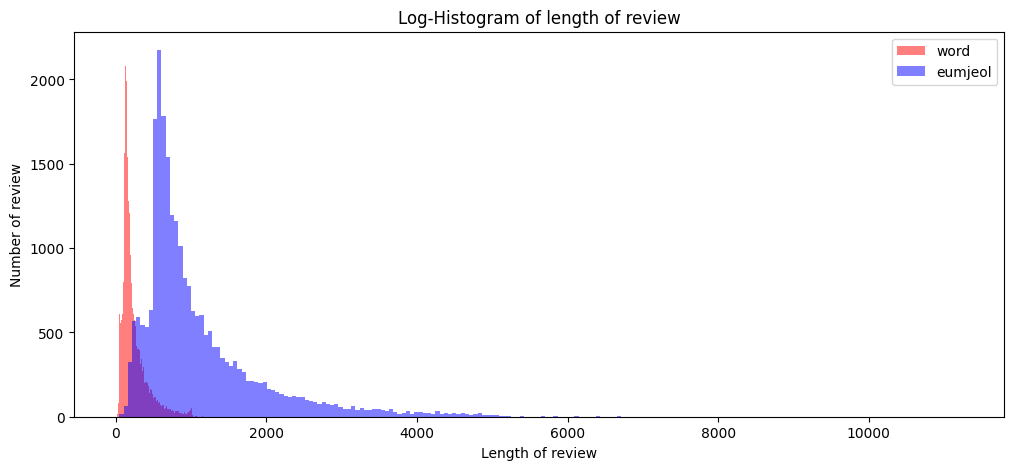

In [23]:
# 그래프에 대한 이미지 사이즈 선언
# figsize: (가로, 세로) 형태의 튜플로 입력
plt.figure(figsize=(12, 5))
# 히스토그램 선언
    # bins: 히스토그램 값들에 대한 버켓 범위
    # range: x축 값의 범위
    # alpha: 그래프 색상 투명도
    # color: 그래프 색상
    # label: 그래프에 대한 라벨
plt.hist(len_tokenized_review, bins=200, alpha=0.5, color= 'r', label='word')
plt.hist(eumjeol_reviews, bins=200, alpha=0.5, color= 'b', label='eumjeol')

# plt.yscale('log')
# 그래프 제목
plt.title('Log-Histogram of length of review')
plt.legend()
# 그래프 x 축 라벨
plt.xlabel('Length of review')
# 그래프 y 축 라벨
plt.ylabel('Number of review')

In [25]:
def summary_token_len(x):
    print('문장 최대길이: {}'.format(np.max(x)))
    print('문장 최소길이: {}'.format(np.min(x)))
    print('문장 평균길이: {:.2f}'.format(np.mean(x)))
    print('문장 길이 표준편차: {:.2f}'.format(np.std(x)))
    print('문장 중간길이: {}'.format(np.median(x)))
    # 사분위의 대한 경우는 0~100 스케일로 되어있음
    print('제 1 사분위 길이: {}'.format(np.percentile(x, 25)))
    print('제 3 사분위 길이: {}'.format(np.percentile(x, 75)))

summary_token_len(len_tokenized_review)

문장 최대길이: 2470
문장 최소길이: 10
문장 평균길이: 233.79
문장 길이 표준편차: 173.73
문장 중간길이: 174.0
제 1 사분위 길이: 127.0
제 3 사분위 길이: 284.0


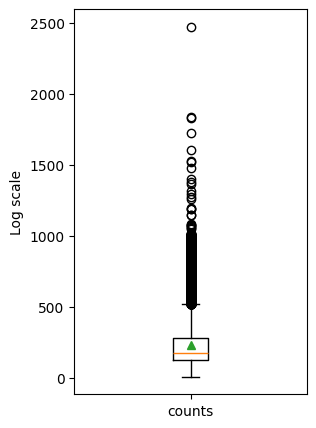

In [27]:
plt.figure(figsize=(3, 5))
# 박스플롯 생성
# 첫번째 파라메터: 여러 분포에 대한 데이터 리스트를 입력
# labels: 입력한 데이터에 대한 라벨
# showmeans: 평균값을 마크함

plt.boxplot(len_tokenized_review,
             tick_labels=['counts'],
             showmeans=True)
# plt.yscale('log')
plt.ylabel('Log scale')
plt.show()

###  WordCloud

In [ ]:
from wordcloud import WordCloud, STOPWORDS

my_stopword = ['br', 'movie', 'movies',
               'seen', 'film', 'seem', 'one',
               'seems', 'look', 'time', 'make',
               'see', 'made', 'show', 'will', 'something'
               'even', 'people', 'scene', 'thing'] + list(STOPWORDS)

{'again', 'http', 'also', "we'll", 'k', 'she', 'hers', 'few', 'ever', 'my', 'once', 'theirs', "here's", "doesn't", 'between', "you're", "i'm", 'down', 'otherwise', 'only', 'were', 'most', 'was', "you'd", 'he', 'could', 'after', "when's", 'for', 'themselves', "it's", 'myself', "won't", 'then', "couldn't", 'both', "she's", 'while', 'no', 'any', "you've", 'himself', 'being', 'all', 'here', 'ours', 'so', 'since', 'there', 'doing', 'not', "we're", 'they', 'this', 'having', 'had', 'is', "shan't", "what's", 'below', 'through', 'from', 'shall', 'which', 'i', 'yourselves', 'should', "we've", "let's", "why's", 'as', "isn't", 'ourselves', 'ought', 'an', 'itself', 'off', 'these', 'be', 'but', 'at', 'very', "didn't", 'do', "who's", 'have', 'herself', "i've", "how's", 'com', 'cannot', "he'll", 'r', "she'd", 'we', 'to', 'more', 'by', 'its', "i'd", "shouldn't", 'yours', "hasn't", 'before', 'other', "wouldn't", 'further', 'or', 'when', 'them', 'like', 'such', 'been', 'me', 'own', 'therefore', 'who', 'w

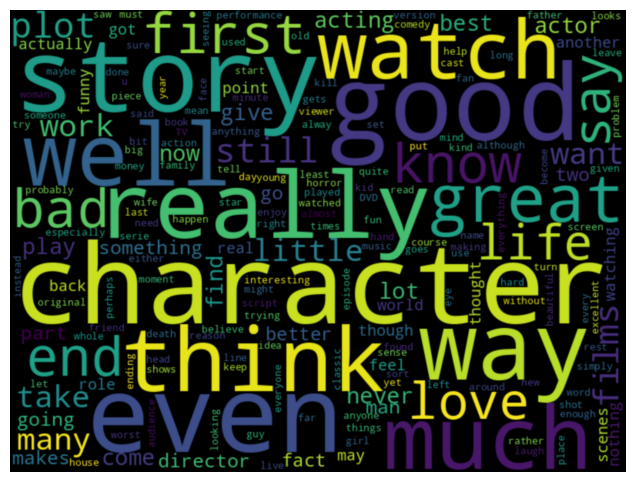

In [34]:

# cloud = WordCloud(stopwords=STOPWORDS,width=800, height=600).generate(" ".join(train_data['review']))
# print(STOPWORDS)
mytext = " ".join(train_data['review']) # '_'.join(['a', 'b', 'c']) 라 하면 "a_b_c"


# stop_words = ["br", "even", "little", "said"] + list(STOPWORDS)
# cloud = WordCloud(stopwords=STOPWORDS, width=800, height=600)
cloud = WordCloud(stopwords=my_stopword, width=800, height=600)


cloud_str = cloud.generate(mytext) #리스트를 문자열로 변환

plt.figure(figsize=(8, 6))
plt.imshow(cloud_str, interpolation='bicubic')
plt.axis('off')
plt.show()

### 데이터 분포

긍정 리뷰 개수: 12500
부정 리뷰 개수: 12500


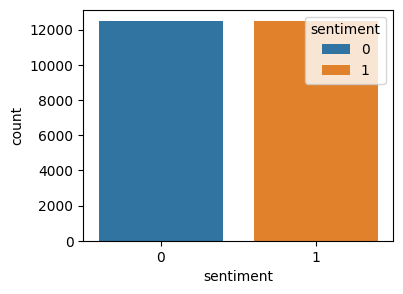

In [41]:
fig, axe = plt.subplots(figsize = (6, 4))
print("긍정 리뷰 개수: {}".format(train_data['sentiment'].value_counts()[1]))
print("부정 리뷰 개수: {}".format(train_data['sentiment'].value_counts()[0]))
fig.set_size_inches(4, 3)
a = sns.countplot(x = 'sentiment', data = train_data, hue = "sentiment")
# a = sns.catplot(x ='sentiment', data = train_data, hue = "sentiment",
#             kind="count")

In [43]:
## String
str_ex1 = '텐서플로우와 머신러닝을 이용한 자연어 처리'
print(str_ex1.split(sep=' '))

## pd.Series
str_pd = pd.Series('텐서플로우와 머신러닝을 이용한 자연어 처리')
print(str_pd.str.split(' '))

A = str_pd.str.split(' ')
A[0]

['텐서플로우와', '머신러닝을', '이용한', '자연어', '처리']
0    [텐서플로우와, 머신러닝을, 이용한, 자연어, 처리]
dtype: object


['텐서플로우와', '머신러닝을', '이용한', '자연어', '처리']

In [45]:
df = pd.DataFrame([[1, 2], [3, 4]], columns= ['A', 'B'])
print(df)
## apply + 함수
def add_one(x):
    x += 1
    return x

## Apply column
df['A'] = df['A'].apply(add_one)
print(df)
print('='*50)

## Apply dataframe
df = df.apply(add_one)
print(df)
print('='*50)

## apply + lambda
df['A'] = df['A'].apply(lambda x: x+1)
print(df)

   A  B
0  1  2
1  3  4
   A  B
0  2  2
1  4  4
   A  B
0  3  3
1  5  5
   A  B
0  4  3
1  6  5


In [54]:
## using Pandas
train_word_counts = train_data['review'].str.split().apply(len)
# train_word_counts2

Text(0, 0.5, 'Number of reviews')

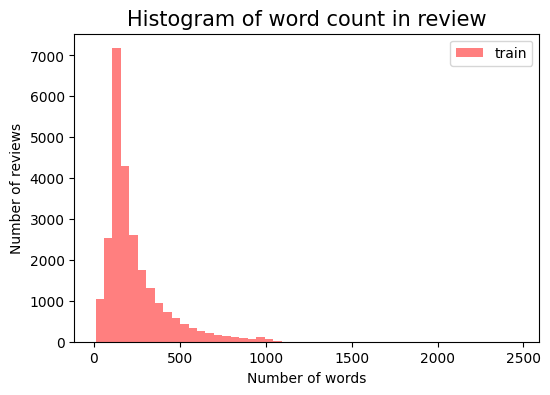

In [55]:
plt.figure(figsize=(6, 4))
k = plt.hist(train_word_counts, bins=50, facecolor='r', alpha = .5, label='train')
# sns.histplot(train_word_counts) # works well

plt.title('Histogram of word count in review', fontsize=15)
# plt.yscale('log')
plt.legend()
plt.xlabel('Number of words', fontsize=10)
plt.ylabel('Number of reviews', fontsize=10)

In [57]:
summary_token_len(train_word_counts)

문장 최대길이: 2470
문장 최소길이: 10
문장 평균길이: 233.79
문장 길이 표준편차: 173.73
문장 중간길이: 174.0
제 1 사분위 길이: 127.0
제 3 사분위 길이: 284.0


### 특수문자, 대,소문자

In [60]:
## 의문문
# sentence = "apple"
# print("a" in sentence) # True
train_data['review'].apply(lambda x: '?' in x)

True

In [61]:
qmarks = np.mean(train_data['review'].apply(lambda x: '?' in x)) # 물음표가 구두점으로 쓰임
fullstop = np.mean(train_data['review'].apply(lambda x: '.' in x)) # 마침표
capital_first = np.mean(train_data['review'].apply(lambda x: x[0].isupper())) #  첫번째 대문자
capitals = np.mean(train_data['review'].apply(lambda x: max([y.isupper() for y in x]))) # 대문자가 몇개
numbers = np.mean(train_data['review'].apply(lambda x: max([y.isdigit() for y in x]))) # 숫자가 몇개)

print('물음표가있는 질문: {:.2f}%'.format(qmarks * 100))
print('마침표가 있는 질문: {:.2f}%'.format(fullstop * 100))
print('첫 글자가 대문자 인 질문: {:.2f}%'.format(capital_first * 100))
print('대문자가있는 질문: {:.2f}%'.format(capitals * 100))
print('숫자가있는 질문: {:.2f}%'.format(numbers * 100))

물음표가있는 질문: 29.55%
마침표가 있는 질문: 99.69%
첫 글자가 대문자 인 질문: 0.00%
대문자가있는 질문: 99.59%
숫자가있는 질문: 56.66%


### HTML tag 제거

In [66]:
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
## nltk 토큰나이징

import nltk
nltk.download("punkt")
nltk.download('stopwords')
from nltk.corpus import stopwords

import re

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [69]:
html_text = \
'''
<p> O’er all the hilltops<br>
    Is quiet now,<br>
    In all the treetops<br>
    Hearest thou<br>
    Hardly a breath;<br>
    The birds are asleep in the trees:<br>
    Wait, soon like these<br>
    Thou too shalt rest.
</p>
'''
print('[1] html_text', html_text)

html_text_soup = BeautifulSoup(html_text, 'html').get_text()
print('[2] html_text_soup: get_text()\n',html_text_soup)
print('[3] html_text_resub\n', re.sub("[^a-zA-Z]", " ",html_text_soup))

[1] html_text 
<p> O’er all the hilltops<br>
    Is quiet now,<br>
    In all the treetops<br>
    Hearest thou<br>
    Hardly a breath;<br>
    The birds are asleep in the trees:<br>
    Wait, soon like these<br>
    Thou too shalt rest.
</p>

[2] html_text_soup: get_text()
 
 O’er all the hilltops
    Is quiet now,
    In all the treetops
    Hearest thou
    Hardly a breath;
    The birds are asleep in the trees:
    Wait, soon like these
    Thou too shalt rest.


[3] html_text_resub
   O er all the hilltops     Is quiet now      In all the treetops     Hearest thou     Hardly a breath      The birds are asleep in the trees      Wait  soon like these     Thou too shalt rest   


In [70]:
review = train_data['review'][0] # 리뷰 중 하나를 가져온다.
review_soup = BeautifulSoup(review).get_text() # HTML 태그 제거
# review_text = BeautifulSoup(review, "html").get_text() # HTML 태그 제거

review_text = re.sub("[^a-zA-Z]", " ", review_soup) # 영어 문자를 제외한 나머지는 모두 공백으로 바꾼다.

print('review:'.ljust(15), review) # <br /><br />Bottom line
print('review_soup:'.ljust(15), review_soup) # (which i think is most people).
print('review_text:'.ljust(15), review_text) # which i think is most people

review:         "With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit whe

In [71]:
stopwords.words('english') # No korean data
stop_words = set(stopwords.words('english')) # 영어 불용어들의 set을 만든다.

review_text = review_text.lower()
# A.split = None (the default value) means split according to any whitespace,
splitted_words = review_text.split() # 소문자 변환 후 단어마다 나눠서 단어 리스트로 만든다.
# print(len(splitted_words)) # 437
words = [w for w in splitted_words if w not in stop_words] # 불용어 제거한 리스트를 만든다
# print(len(words)) # 219

In [72]:
print(review_text)
print(words)

 with all this stuff going down at the moment with mj i ve started listening to his music  watching the odd documentary here and there  watched the wiz and watched moonwalker again  maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent  moonwalker is part biography  part feature film which i remember going to see at the cinema when it was originally released  some of it has subtle messages about mj s feeling towards the press and also the obvious message of drugs are bad m kay visually impressive but of course this is all about michael jackson so unless you remotely like mj in anyway then you are going to hate this and find it boring  some may call mj an egotist for consenting to the making of this movie but mj and most of his fans would say that he made it for the fans which if true is really nice of him the actual feature film bit when it finally starts is only on for    mi

In [73]:
clean_review = ' '.join(words) # 단어 리스트들을 다시 하나의 글로 합친다.
print(clean_review)

stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighties maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle messages mj feeling towards press also obvious message drugs bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fans would say made fans true really nice actual feature film bit finally starts minutes excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord wants mj dead bad beyond mj overheard plans nah joe pesci character ranted wanted people know supplying drugs etc dunno maybe hates mj music lots cool things like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually directors hate working

In [74]:
def preprocessing( review, remove_stopwords = False ):
    # 불용어 제거는 옵션으로 선택 가능하다.

    # 1. HTML 태그 제거
    review_text = BeautifulSoup(review).get_text()

    # 2. 영어가 아닌 특수문자들을 공백(" ")으로 바꾸기
    review_text = re.sub("[^a-zA-Z]", " ", review_text)

    # 3. 대문자들을 소문자로 바꾸고 공백단위로 텍스트들 나눠서 리스트로 만든다.
    words = review_text.lower().split()

    if remove_stopwords:
        # 4. 불용어들을 제거

        #영어에 관련된 불용어 불러오기
        stops = set(stopwords.words("english"))
        # 불용어가 아닌 단어들로 이루어진 새로운 리스트 생성
        words = [w for w in words if not w in stops]
        # 5. 단어 리스트를 공백을 넣어서 하나의 글로 합친다.
        clean_review = ' '.join(words)

    else: # 불용어 제거하지 않을 때
        clean_review = ' '.join(words)

    return clean_review

In [75]:
clean_train_reviews =  reviews.apply(preprocessing, args = False)

# clean_train_reviews = []
# for review in train_data['review']:
#     clean_train_reviews.append(preprocessing(review, remove_stopwords = True))

# 전처리한 데이터 출력
clean_train_reviews[1]

'the classic war of the worlds by timothy hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate h g wells classic book mr hines succeeds in doing so i and those who watched his film with me appreciated the fact that it was not the standard predictable hollywood fare that comes out every year e g the spielberg version with tom cruise that had only the slightest resemblance to the book obviously everyone looks for different things in a movie those who envision themselves as amateur critics look only to criticize everything they can others rate a movie on more important bases like being entertained which is why most people never agree with the critics we enjoyed the effort mr hines put into being faithful to h g wells classic novel and we found it to be very entertaining this made it easy to overlook what the critics perceive to be its shortcomings'

In [76]:
clean_train_df = pd.DataFrame({'review': clean_train_reviews, 'sentiment': train_data['sentiment']})


print(type(clean_train_df.review))
print(clean_train_df.head())

clean_train_df.to_csv('./csv/clean_train_data.csv', index = False)

<class 'pandas.core.series.Series'>
                                              review  sentiment
0  with all this stuff going down at the moment w...          1
1  the classic war of the worlds by timothy hines...          1
2  the film starts with a manager nicholas bell g...          0
3  it must be assumed that those who praised this...          0
4  superbly trashy and wondrously unpretentious s...          1


## Text similarity를 이용한 영화 추천 시스템

### CountVectorizer

In [84]:
## CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords

In [81]:
text_data = ['나는 배가 고프다',
             '내일 점심 뭐먹지',
             '내일 공부 해야겠다',
             '점심 먹고 공부 해야지']

## 영어

# count_vectorizer = CountVectorizer(stop_words=["the", "a", "an", "is", "not"])
# print(count_vectorizer.fit_transform(text_data).toarray())

count_vectorizer = CountVectorizer()
count_vectorizer.fit(text_data)
print(count_vectorizer.vocabulary_)

{'나는': 2, '배가': 6, '고프다': 0, '내일': 3, '점심': 7, '뭐먹지': 5, '공부': 1, '해야겠다': 8, '먹고': 4, '해야지': 9}


In [ ]:
# Make Document-Term Matrix (DTM)

sentence = [text_data[0]] # ['나는 배가 고프다']
print(count_vectorizer.transform(sentence))
print(count_vectorizer.transform(sentence).toarray())
print("="*50)
print("vocabulary_: \n")
display(count_vectorizer.vocabulary_)
print("="*50)
print("Document-Term Matrix (DTM): CountVectorizer \n")
print(count_vectorizer.transform(text_data).toarray())

  (0, 0)	1
  (0, 2)	1
  (0, 6)	1
[[1 0 1 0 0 0 1 0 0 0]]
vocabulary_: 



{'나는': 2,
 '배가': 6,
 '고프다': 0,
 '내일': 3,
 '점심': 7,
 '뭐먹지': 5,
 '공부': 1,
 '해야겠다': 8,
 '먹고': 4,
 '해야지': 9}

Document-Term Matrix (DTM): CountVectorizer 

[[1 0 1 0 0 0 1 0 0 0]
 [0 0 0 1 0 1 0 1 0 0]
 [0 1 0 1 0 0 0 0 1 0]
 [0 1 0 0 1 0 0 1 0 1]]


In [83]:
## TfidfVectorizer
# text_data = ['나는 배가 고프다',
#              '내일 점심 뭐먹지',
#              '내일 공부 해야겠다',
#              '점심 먹고 공부 해야지']
text_data = ["먹고 싶은 사과",
             "먹고 싶은 바나나",
             "길고 노란 바나나 바나나",
             "저는 과일이 좋아요"]

tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(text_data)
display(tfidf_vectorizer.vocabulary_)

print("="*50)
print("Document-Term Matrix (DTM): TfidfVectorizer \n")
text_idf_arr = tfidf_vectorizer.transform(text_data).toarray()
print(text_idf_arr)

{'먹고': 3,
 '싶은': 6,
 '사과': 5,
 '바나나': 4,
 '길고': 1,
 '노란': 2,
 '저는': 7,
 '과일이': 0,
 '좋아요': 8}

Document-Term Matrix (DTM): TfidfVectorizer 

[[0.         0.         0.         0.52640543 0.         0.66767854
  0.52640543 0.         0.        ]
 [0.         0.         0.         0.57735027 0.57735027 0.
  0.57735027 0.         0.        ]
 [0.         0.47212003 0.47212003 0.         0.7444497  0.
  0.         0.         0.        ]
 [0.57735027 0.         0.         0.         0.         0.
  0.         0.57735027 0.57735027]]


### 코사인 유사도를 이용한 추천 시스템

In [89]:
data = pd.read_csv('./csv/movies_metadata.csv', low_memory=False)
data.head(2)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0


In [90]:
# 상위 2만개의 샘플을 data에 저장
data = data.head(20000)
# overview 열에 존재하는 모든 결측값을 전부 카운트하여 출력
print('overview 열의 결측값의 수:',data['overview'].isnull().sum())
# 결측값을 빈 값으로 대체
data['overview'] = data['overview'].fillna('')

overview 열의 결측값의 수: 135


In [91]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(data['overview'])
print('TF-IDF 행렬의 크기(shape) :',tfidf_matrix.shape)

TF-IDF 행렬의 크기(shape) : (20000, 47487)


In [92]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print('코사인 유사도 연산 결과 :',cosine_sim.shape)

코사인 유사도 연산 결과 : (20000, 20000)


In [93]:
title_to_index = dict(zip(data['title'], data.index))

# 영화 제목 Father of the Bride Part II의 인덱스를 리턴
idx = title_to_index['Father of the Bride Part II']
print(idx)


4


In [94]:
def get_recommendations(title, cosine_sim=cosine_sim):
    # 선택한 영화의 타이틀로부터 해당 영화의 인덱스를 받아온다.
    idx = title_to_index[title]

    # 해당 영화와 모든 영화와의 유사도를 가져온다.
    sim_scores = list(enumerate(cosine_sim[idx]))

    # 유사도에 따라 영화들을 정렬한다.
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 가장 유사한 10개의 영화를 받아온다.
    sim_scores = sim_scores[1:11]

    # 가장 유사한 10개의 영화의 인덱스를 얻는다.
    movie_indices = [idx[0] for idx in sim_scores]

    # 가장 유사한 10개의 영화의 제목을 리턴한다.
    return data['title'].iloc[movie_indices]


In [95]:
get_recommendations('The Dark Knight Rises')

12481                            The Dark Knight
150                               Batman Forever
1328                              Batman Returns
15511                 Batman: Under the Red Hood
585                                       Batman
9230          Batman Beyond: Return of the Joker
18035                           Batman: Year One
19792    Batman: The Dark Knight Returns, Part 1
3095                Batman: Mask of the Phantasm
10122                              Batman Begins
Name: title, dtype: object

In [100]:
np.sqrt(4*(3**2))

6.0

In [104]:
a = np.array([1, 2, 3, 4])
b = np.array([4, 5, 6, 7])

(a*b).sum()/(np.sqrt((a*a).sum())*np.sqrt((b*b).sum()))

0.9759000729485332